### Clase `VRPTW` para el Problema de Enrutamiento de Vehículos con Ventanas de Tiempo (VRPTW)

Este bloque define una clase `VRPTW` que modela una instancia del problema de enrutamiento de vehículos con ventanas de tiempo. La clase se inicializa con coordenadas de clientes, ventanas de tiempo, demandas y la capacidad del vehículo.

- `__init__`: Inicializa los datos del problema y calcula una matriz de distancias entre todos los nodos.
- `_compute_distances`: Calcula la distancia euclidiana entre cada par de nodos (incluido el depósito).
- `evaluate`: Evalúa una solución representada como una lista de rutas. Calcula la distancia total recorrida por los vehículos, considerando restricciones como la capacidad del vehículo y las ventanas de tiempo. Si alguna restricción se viola, devuelve infinito como penalización.

Este código importa también un conjunto de clientes desde un archivo externo llamado `clientes.py`.


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from clientes import clientes


class VRPTW:
    def __init__(self, coordinates, time_windows, demands, vehicle_capacity):
        self.num_customers = len(coordinates)
        self.vehicle_capacity = vehicle_capacity
        self.time_windows = time_windows
        self.demands = demands
        self.coordinates = coordinates
        self.distances = self._compute_distances()

    def _compute_distances(self):
        d = np.zeros((self.num_customers, self.num_customers))
        for i in range(self.num_customers):
            for j in range(self.num_customers):
                x1, y1 = self.coordinates[i]
                x2, y2 = self.coordinates[j]
                d[i, j] = np.hypot(x2 - x1, y2 - y1)
        return d

    def evaluate(self, routes, speed: float = 1000.0) -> float:
        total = 0.0
        for route in routes:
            if not route:
                continue
            load = 0
            t = 0  # tiempo actual
            prev = 0  # depósito
            for node in route:
                load += self.demands[node]
                if load > self.vehicle_capacity:
                    return float("inf")

                travel_time = self.distances[prev][node] / speed
                arrival = t + travel_time
                start_tw, end_tw = self.time_windows[node]
                if end_tw == 999:
                    end_tw = 1e9  # ventana abierta
                if arrival > end_tw:
                    return float("inf")
                t = max(arrival, start_tw)
                total += self.distances[prev][node]
                prev = node
            total += self.distances[prev][0]  # regreso al depósito
        return total


### Clase `Particle` para el Algoritmo PSO (Particle Swarm Optimization)

Esta clase representa una partícula en el contexto del algoritmo de optimización por enjambre de partículas (PSO) aplicado al problema VRPTW.

- `position`: Vector que representa una solución codificada. Incluye `n_customers` elementos y `2 * n_vehicles` elementos adicionales para ayudar a definir particiones entre rutas.
- `velocity`: Vector de velocidad que se usa para actualizar la posición de la partícula en el espacio de búsqueda.
- `best_position`: Mejor posición encontrada por esta partícula hasta el momento (en términos de costo).
- `best_cost`: Costo asociado a la mejor posición encontrada.

Cada partícula busca mejorar su solución a través de iteraciones, influenciada por su experiencia propia y la del grupo.

In [2]:
class Particle:
    def __init__(self, n_customers: int, n_vehicles: int):
        self.position = np.random.rand(n_customers + 2 * n_vehicles)
        self.velocity = np.zeros_like(self.position)
        self.best_position = self.position.copy()
        self.best_cost = float("inf")


### Clase `PSO`: Optimización por Enjambre de Partículas para el VRPTW

La clase `PSO` implementa el algoritmo **Particle Swarm Optimization** adaptado al **Vehicle Routing Problem with Time Windows (VRPTW)**.

#### Parámetros principales:
- `vrp`: Instancia del problema VRPTW.
- `num_particles`: Número de partículas en el enjambre (soluciones exploradas en paralelo).
- `iterations`: Número de iteraciones del algoritmo.
- `num_vehicles`: Cantidad de vehículos disponibles.

#### Componentes clave del algoritmo:
- **`_decode(pos)`**: Decodifica una solución (posición de la partícula) en rutas factibles para vehículos, considerando la prioridad y la capacidad.
- **`optimize()`**: Ejecuta el bucle principal del PSO, actualizando las velocidades y posiciones de las partículas según las mejores soluciones individuales y globales encontradas.
- **`plot_convergence()`**: Muestra un gráfico con la evolución del mejor costo global a lo largo de las iteraciones.
- **`plot_routes()`**: Visualiza las rutas encontradas por la mejor partícula global al final del proceso.

El PSO utiliza parámetros de inercia (`w`) y coeficientes de atracción cognitiva, social, local y vecinal para guiar la búsqueda. La combinación de estas influencias permite explorar el espacio de soluciones de manera eficiente.


In [3]:
class PSO:
    def __init__(self, vrp: VRPTW, num_particles: int = 30, iterations: int = 200):
        self.vrp = vrp
        self.n_particles = num_particles
        self.iterations = iterations
        self.num_vehicles = 15
        self.particles = [Particle(vrp.num_customers, self.num_vehicles) for _ in range(num_particles)]
        self.global_best_position = None
        self.global_best_cost = float("inf")
        # parámetros PSO
        self.w_start, self.w_end = 0.9, 0.1
        self.cp, self.cg, self.cl, self.cn = 2.0, 2.0, 1.5, 1.5
        self.history = []

    # --- utilidades -----------------------------------------------------

    def _decode(self, pos):
        n = self.vrp.num_customers
        m = self.num_vehicles
        priority = np.argsort(pos[:n])
        routes = [[] for _ in range(m)]
        ref = pos[n:].reshape(m, 2)
        capacities = [self.vrp.vehicle_capacity] * m

        for cust in priority:
            demand = self.vrp.demands[cust]
            cx, cy = self.vrp.coordinates[cust]
            # Solo vehículos con capacidad suficiente
            feasible = [i for i in range(m) if capacities[i] >= demand]
            if not feasible:
                # Si ningún vehículo puede llevarlo, asigna al primero (solución infactible)
                routes[0].append(cust)
                capacities[0] -= demand
                continue
            # Elige el vehículo más cercano con capacidad suficiente
            d = [np.hypot(cx - ref[i][0], cy - ref[i][1]) if i in feasible else np.inf for i in range(m)]
            idx = int(np.argmin(d))
            routes[idx].append(cust)
            capacities[idx] -= demand
        return [r for r in routes if r]

    # --- PSO principal --------------------------------------------------
    def optimize(self):
        for it in range(self.iterations):
            w = self.w_end + (self.iterations - it) * (self.w_start - self.w_end) / self.iterations
            # evaluación
            for p in self.particles:
                cost = self.vrp.evaluate(self._decode(p.position))
                if cost < p.best_cost:
                    p.best_cost, p.best_position = cost, p.position.copy()
                if cost < self.global_best_cost:
                    self.global_best_cost, self.global_best_position = cost, p.position.copy()
            self.history.append(self.global_best_cost)
            # actualización
            for p in self.particles:
                lbest = random.choice(self.particles).best_position
                nbest = random.choice(self.particles).best_position
                r1, r2, r3, r4 = np.random.rand(4)
                p.velocity = (
                    w * p.velocity
                    + self.cp * r1 * (p.best_position - p.position)
                    + self.cg * r2 * (self.global_best_position - p.position)
                    + self.cl * r3 * (lbest - p.position)
                    + self.cn * r4 * (nbest - p.position)
                )
                p.position += p.velocity
        print(f"Mejor costo: {self.global_best_cost if self.global_best_cost < 1e18 else 'inf'}")

    # --- gráficos -------------------------------------------------------
    def plot_convergence(self):
        plt.plot(self.history)
        plt.title("Convergencia PSO")
        plt.xlabel("Iteración")
        plt.ylabel("Costo global")
        plt.grid(True)
        plt.show()

    def plot_routes(self):
        """
        Dibuja las rutas correspondientes a la mejor partícula global
        encontrada (self.global_best_position).
        """
        if self.global_best_position is None:
            print("No se generó una solución factible.")
            return

        routes = self._decode(self.global_best_position)
        colors = plt.colormaps.get_cmap("tab20")          # hasta 20 colores
        depot_x, depot_y = self.vrp.coordinates[0]

        plt.figure(figsize=(6, 6))
        for i, route in enumerate(routes):
            xs = [depot_x] + [self.vrp.coordinates[n][0] for n in route] + [depot_x]
            ys = [depot_y] + [self.vrp.coordinates[n][1] for n in route] + [depot_y]
            plt.plot(xs, ys, "-o", color=colors(i), label=f"Vehículo {i+1}")

        plt.title("Rutas encontradas por PSO")
        plt.xlabel("Coordenada X")
        plt.ylabel("Coordenada Y")
        plt.legend()
        plt.grid(True)
        plt.axis("equal")          # mantienen escala 1:1
        plt.show()


### Ejecución del PSO sobre el problema VRPTW

En esta sección se prepara la instancia del problema y se ejecuta el algoritmo PSO para encontrar rutas óptimas:

1. **Preprocesamiento de clientes:**
   - Se ajustan las ventanas de tiempo de cada cliente a un rango amplio (`0` a `999`) usando la lista `cli_relax`.
   - Se extraen:
     - `coords`: Coordenadas de cada cliente.
     - `time_windows`: Ventanas de tiempo (simuladas abiertas en este caso).
     - `demands`: Demanda de cada cliente.

2. **Inicialización del problema:**
   - `vrp`: Se crea una instancia de `VRPTW` con la información de clientes y una capacidad de vehículo de `10`.

3. **Optimización:**
   - `pso`: Se inicializa el algoritmo PSO con 30 partículas y 200 iteraciones.
   - `pso.optimize()`: Ejecuta la optimización y guarda el mejor resultado encontrado.
   - `pso.plot_convergence()`: Muestra la evolución del costo global a lo largo del tiempo.
   - `pso.plot_routes()`: Visualiza gráficamente las rutas óptimas halladas.

Este bloque combina la definición del problema con la ejecución y visualización de resultados para evaluar el rendimiento del PSO aplicado al VRPTW.


Mejor costo: 173232.66810238292


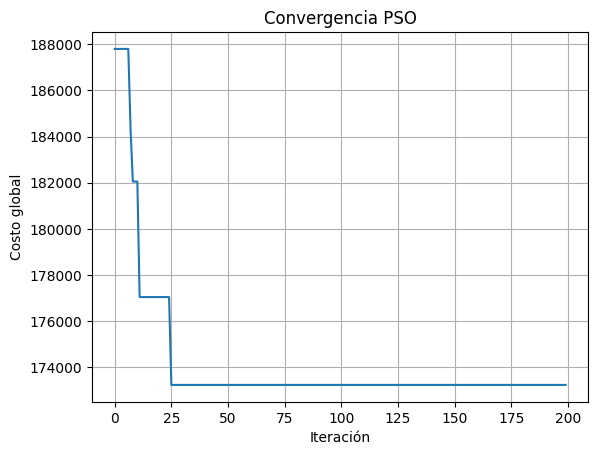

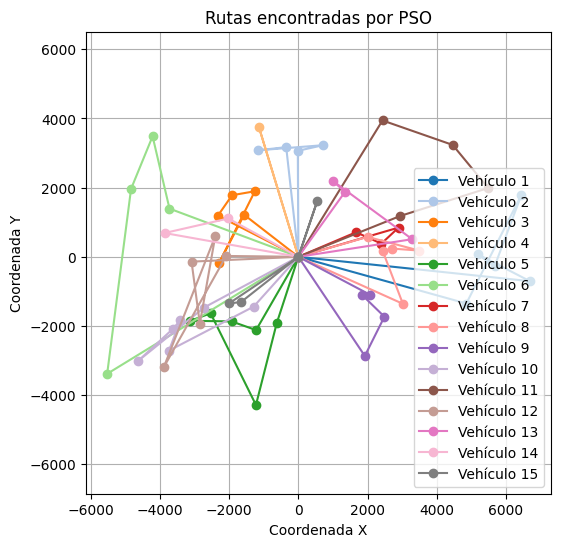

In [4]:

cli_relax = [(x, y, 0, 999, d) for x, y, _, _, d in clientes]
coords       = [(x, y) for x, y, *_ in cli_relax]
time_windows = [(s, e) for *_, s, e, _ in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]
demands      = [d for *_, d in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]

vrp  = VRPTW(coords, time_windows, demands, vehicle_capacity=10)  # capacidad real
pso  = PSO(vrp, num_particles=30, iterations=200)                  # búsqueda moderada
pso.optimize()
pso.plot_convergence()
pso.plot_routes()        

### Propuesta de mejora: Búsqueda Aleatoria de Hiperparámetros para PSO

En este bloque se implementa un procedimiento de **Random Search** para encontrar la mejor configuración de hiperparámetros del algoritmo PSO aplicado al problema VRPTW. La idea es ejecutar múltiples experimentos con combinaciones aleatorias y quedarse con la mejor según el costo obtenido.

#### Descripción de los pasos:

1. **Inicialización**:
   - Se definen las variables para guardar el mejor resultado encontrado (`best_cost`, `best_params`, etc.).

2. **Búsqueda aleatoria** (`for trial in range(n_trials)`):
   - En cada intento:
     - Se seleccionan aleatoriamente valores para los hiperparámetros del PSO:
       - `num_particles`: número de partículas (10 a 50).
       - `iterations`: iteraciones de optimización (50 a 300).
       - `w_start`, `w_end`: límites del factor de inercia.
       - `cp`, `cg`, `cl`, `cn`: coeficientes cognitivo, global, local y de vecindad.
     - Se instancia y ejecuta el PSO con estos parámetros.
     - Se evalúa el costo de la mejor solución encontrada.
     - Si es mejor que el anterior, se actualiza el mejor resultado.

3. **Reporte de resultados**:
   - Se imprime el conjunto de parámetros óptimos y el costo correspondiente.
   - Se grafica la evolución del mejor experimento (`best_history`).
   - Se visualizan las rutas encontradas por el mejor modelo.

#### Objetivo:

Este proceso busca mejorar el rendimiento del PSO ajustando sus parámetros de forma automática, sin necesidad de hacerlo manualmente. Esto permite obtener soluciones más robustas al problema de enrutamiento de vehículos con ventanas de tiempo (VRPTW).


Mejor costo: 168536.71497116474
Trial 1: cost=168536.71, params=37, 259, 0.68, 0.14, 2.94, 1.49, 1.90, 1.19
Mejor costo: 167060.2173179528
Trial 2: cost=167060.22, params=24, 248, 0.70, 0.14, 1.02, 2.23, 1.91, 0.86
Mejor costo: 177666.9191088543
Trial 3: cost=177666.92, params=35, 69, 0.71, 0.31, 2.12, 2.22, 1.17, 1.77
Mejor costo: 167556.90499199647
Trial 4: cost=167556.90, params=34, 118, 0.69, 0.15, 2.12, 3.00, 0.56, 0.69
Mejor costo: 178109.0385673735
Trial 5: cost=178109.04, params=49, 249, 0.89, 0.35, 1.62, 2.72, 1.26, 1.79
Mejor costo: 168826.41600446342
Trial 6: cost=168826.42, params=30, 105, 0.61, 0.37, 2.01, 1.38, 0.68, 0.89
Mejor costo: 168256.8302861513
Trial 7: cost=168256.83, params=15, 138, 0.76, 0.20, 1.58, 1.11, 1.48, 0.91
Mejor costo: 165801.69437407804
Trial 8: cost=165801.69, params=45, 162, 0.88, 0.48, 1.30, 2.94, 1.81, 0.58
Mejor costo: 159761.0305952801
Trial 9: cost=159761.03, params=18, 211, 0.61, 0.49, 1.01, 1.67, 1.38, 1.97
Mejor costo: 166288.9105440942
Tri

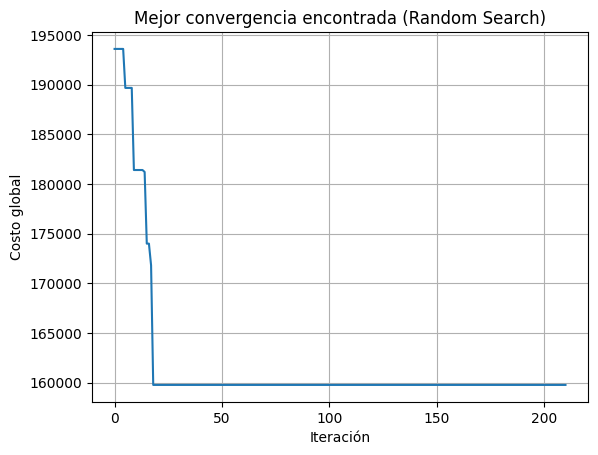

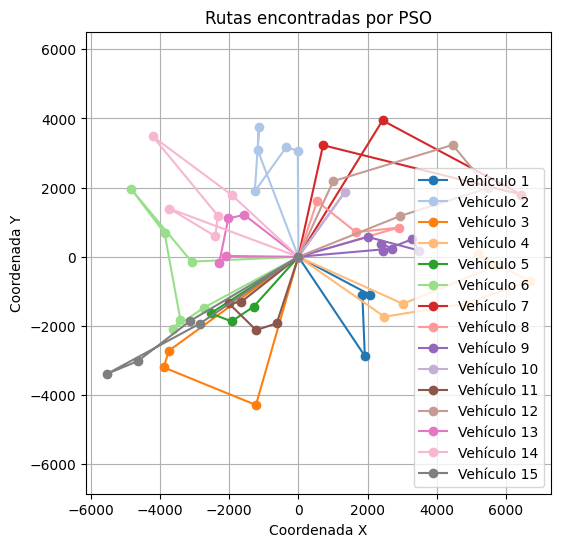

159761.0305952801

In [ ]:

import copy

def random_search_pso(vrp, n_trials=10):
    best_cost = float("inf")
    best_params = None
    best_history = None
    best_routes = None
    best_position = None

    for trial in range(n_trials):
        # Rango de hiperparámetros
        num_particles = np.random.randint(10, 50)
        iterations = np.random.randint(50, 300)
        w_start = np.random.uniform(0.5, 1.0)
        w_end = np.random.uniform(0.05, 0.5)
        cp = np.random.uniform(1.0, 3.0)
        cg = np.random.uniform(1.0, 3.0)
        cl = np.random.uniform(0.5, 2.0)
        cn = np.random.uniform(0.5, 2.0)

        # Instancia PSO con parámetros aleatorios
        pso = PSO(vrp, num_particles=num_particles, iterations=iterations)
        pso.w_start = w_start
        pso.w_end = w_end
        pso.cp = cp
        pso.cg = cg
        pso.cl = cl
        pso.cn = cn

        pso.optimize()
        cost = pso.global_best_cost

        print(f"Trial {trial+1}: cost={cost:.2f}, params={num_particles}, {iterations}, {w_start:.2f}, {w_end:.2f}, {cp:.2f}, {cg:.2f}, {cl:.2f}, {cn:.2f}")

        if cost < best_cost:
            best_cost = cost
            best_params = (num_particles, iterations, w_start, w_end, cp, cg, cl, cn)
            best_history = copy.deepcopy(pso.history)
            best_routes = pso._decode(pso.global_best_position)
            best_position = pso.global_best_position.copy()

    print("\nMejores parámetros encontrados:")
    print(f"num_particles={best_params[0]}, iterations={best_params[1]}, w_start={best_params[2]:.2f}, w_end={best_params[3]:.2f}, cp={best_params[4]:.2f}, cg={best_params[5]:.2f}, cl={best_params[6]:.2f}, cn={best_params[7]:.2f}")
    print(f"Mejor costo: {best_cost:.2f}")

    # Puedes graficar la convergencia del mejor experimento
    plt.plot(best_history)
    plt.title("Mejor convergencia encontrada (Random Search)")
    plt.xlabel("Iteración")
    plt.ylabel("Costo global")
    plt.grid(True)
    plt.show()

    # Graficar la mejor ruta encontrada
    if best_position is not None:
        # Instancia temporal para graficar usando el mejor global encontrado
        pso_best = PSO(vrp)
        pso_best.global_best_position = best_position
        pso_best.plot_routes()
    return best_cost

# Ejecuta la búsqueda aleatoria
best_cost = random_search_pso(vrp, n_trials=10)
# ...existing code...

### Cálculo del Costo Total de las Rutas (Benchmark del Artículo)

Este bloque de código calcula el **costo total (distancia recorrida)** para un conjunto de rutas extraídas del artículo base sobre el VRPTW (Vehicle Routing Problem with Time Windows). Se utilizan las coordenadas de los clientes proporcionadas por el problema y las rutas propuestas por la solución del artículo.

#### Pasos:
1. Se define la lista `clientes`, que contiene las coordenadas `(x, y)` de cada cliente, incluyendo el depósito (índice 0).
2. Se define la lista `rutas`, donde cada sublista representa el recorrido de un vehículo, comenzando y terminando en el depósito.
3. Se implementa la función `distancia(p1, p2)` para calcular la distancia euclidiana entre dos puntos.
4. Se recorre cada ruta y se acumulan las distancias entre pares consecutivos de clientes para obtener el **costo total**.

Este valor sirve como referencia para comparar los resultados del algoritmo PSO implementado y evaluar qué tan cerca (o mejor) se encuentran sus soluciones respecto al benchmark del artículo.


In [10]:
import math

# Coordenadas de los clientes
clientes = [
    (0.0, 0.0), (1006.1, 2187.3), (4461.8, 3235.3), (-2327.6, 1190.7), (-3871.2, 687.7),
    (-1932.6, -1867.7), (-3089.9, -139.6), (-2289.0, -169.0), (-3409.6, -1831.0), 
    (-1223.4, -2118.8), (2487.8, -1732.2), (-2538.7, -1633.9), (-4216.0, 3485.3), 
    (1346.8, 1875.2), (5489.3, 1989.5), (1668.7, 710.3), (-2403.8, 596.6), 
    (-3727.1, 1393.1), (-1140.4, 3747.2), (4856.3, -1350.2), (6694.6, -705.1), 
    (3290.8, 509.1), (1921.0, -2867.0), (6451.2, 1795.1), (5180.6, 78.7), 
    (-2727.1, -1467.0), (-1227.1, -4284.9), (-2007.7, -1349.1), (-3742.7, -2713.0), 
    (-627.5, -1923.4), (3021.6, -1359.3), (2399.9, 381.4), (-4636.2, -3012.2), 
    (2003.8, 576.0), (3493.2, 180.8), (2895.9, 844.5), (-3627.7, -2082.4), 
    (2707.3, 237.8), (5671.2, -280.2), (-3126.2, -1850.8), (-5529.7, -3383.5), 
    (-1656.8, -1306.8), (1850.6, -1111.3), (2947.1, 1181.6), (-2849.7, -1932.0), 
    (2059.2, -1091.0), (-4838.7, 1963.8), (-1293.9, -1441.1), (-3895.3, -3197.8), 
    (-1568.3, 1215.1), (713.6, 3227.5), (-2087.7, 24.8), (-1259.0, 1895.7), 
    (542.6, 1604.8), (-2026.4, 1108.0), (-1917.8, 1780.6), (-16.8, 3064.5), 
    (2436.9, 171.9), (-352.5, 3171.6), (-1175.4, 3079.4), (2433.1, 3942.9)
]

# Rutas de los vehículos (cada sublista representa la ruta de un vehículo)
rutas = [
    [0, 59, 58, 18, 12, 27, 0],
    [0, 52, 55, 50, 48, 0],
    [0, 46, 0],
    [0, 3, 49, 17, 54, 0],
    [0, 7, 51, 16, 6, 4, 32, 0],
    [0, 8, 36, 28, 44, 11, 25, 0],
    [0, 60, 13, 1, 53, 0],
    [0, 41, 5, 56, 0],
    [0, 47, 39, 40, 0],
    [0, 9, 29, 26, 0],
    [0, 15, 30, 19, 0],
    [0, 14, 2, 23, 0],
    [0, 33, 35, 21, 43, 24, 0],
    [0, 31, 34, 37, 57, 20, 38, 0],
    [0, 45, 42, 22, 10, 0]
]

# Función para calcular la distancia euclidiana entre dos puntos
def distancia(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

# Calcular el costo total (distancia total recorrida)
costo_totalArticulo = 0
for ruta in rutas:
    for i in range(len(ruta) - 1):
        origen = clientes[ruta[i]]
        destino = clientes[ruta[i + 1]]
        costo_totalArticulo += distancia(origen, destino)

costo_totalArticulo


187464.6335291323

In [ ]:
# ...existing code...

# --- Comparación final de costos: Random Search PSO vs Artículo ---

print("Comparación de costos:")
print(f"Costo total del artículo: {costo_totalArticulo:.2f}")
print(f"Mejor costo encontrado por Random Search PSO: {best_cost:.2f}")

if best_cost < costo_totalArticulo:
    print("¡El PSO con Random Search encontró una mejor solución que el artículo!")
elif best_cost > costo_totalArticulo:
    print("La solución del artículo es mejor que la encontrada por PSO con Random Search.")
else:
    print("Ambos métodos encontraron soluciones con el mismo costo.")

print(f"Diferencia absoluta: {best_cost - costo_totalArticulo:.2f}")
print(f"Diferencia relativa: {(best_cost - costo_totalArticulo) / costo_totalArticulo * 100:.2f}%")
# ...existing code...

Comparación de costos:
Costo total del artículo: 187464.63


NameError: name 'best_cost' is not defined